### Machine Learning and `scikitlearn`

This assignment is meant to fill out your work using `sklearn` to prepare your data and build predictive models.  Chapter 2 from Geron's [*Hands on Machine Learning with `scikitlearn` and `pytorch`*](https://search.library.nyu.edu/permalink/01NYU_INST/1e86n5m/cdi_proquest_ebookcentralchapters_30168989_18_29) will guide you through your work.  To begin, skim the chapter and get a sense for the workflow for modeling the California Housing dataset.  Go back and pay special attention to the transformers introduced including:

- `StandardScaler`
- `MaxMinScaler`
- `OrdinalEncoder`
- `OneHotEncoder`
- `SimpleImputer`

As far as modeling goes, make sure to understand the `TransformedTargetRegressor` and when/why you would use this instead of `LinearRegression` alone.  Use transformers to combine multiple preprocessing steps with `Pipeline` and apply specific transformers to specific column with the `ColumnTransformer` along with their helpers `make_column_selector` and `make_column_transformer`.

Last, pay close attention to `cross_val_score` and `GridSearchCV` to select the "best" model and tune hyperparameters.

**Problem**

In your own words, summarize Geron's modeling workflow and how they approached predicting the housing prices.  Don't be technical or name specific `sklearn` elements -- this should be a non-technical explanation using 3-5 paragraphs with complete sentences and plain language.

Geron begins by framing the problem in business terms before writing any code. The goal is not just to build a model, but to replace a manual process where experts estimate housing prices and are often off by more than 30%. Understanding how the predictions will actually be used, feeding into an investment decision system, shapes every choice that follows, from how performance is measured to how much effort is spent on tuning.

Once the data is in hand, Geron immediately sets aside a portion as a test set and locks it away until the very end. Looking at it too early can subtly influence modeling decisions in ways that make the final results look better than they really are. The split is also done carefully to preserve the income distribution of the full dataset, since income turns out to be the strongest predictor of housing prices.

With the training data secured, Geron spends real time exploring it before building anything. He maps geographic patterns, plots distributions, and measures how each variable relates to price. He also constructs new variables from combinations of existing ones. For instance, the ratio of bedrooms to total rooms is more informative than either count on its own. This phase is about developing intuition, not producing output.

Before any model sees the data, Geron builds a systematic and reusable preparation process. Missing values are filled in using statistics learned from the training data, text categories are converted into numbers, and all features are brought to a common scale so that no single variable dominates just because of its units. Building this as an automated sequence rather than a series of manual steps ensures consistency and prevents information from the test set from leaking into the training process.

Finally, Geron trains several model types and evaluates each one across multiple splits of the training data rather than relying on a single result. Simpler models underfit while more complex ones risk memorizing the training data. The most promising model is then systematically tuned by searching across different configurations. Only once the best setup is confirmed does he evaluate it against the locked test set, producing a single clean measurement of how the model will perform on data it has never seen.

**Problem**

Using Geron's work as a guide, prepare a similar pipeline to build a regression model on a dataset of your choice from the sources in the beginning of the chapter.  Your work should utilize feature engineering and a pipeline with transformers and models -- `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`, and `SVR` -- that have been grid searched and evaluated against a test set.  

Briefly describe your results and if you can determine anything about what features from the data were most important to the success of your model.  

# Boston Housing Price Prediction

---
## 0. Setup & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load Boston Housing data from CMU StatLib
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
feature = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
price = raw_df.values[1::2, 2]

feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE',
                 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

df = pd.DataFrame(feature, columns=feature_names)

# target
df['MEDV'] = price

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


---
## 1. Exploratory Data Analysis (EDA)
*(scatter plots, correlation matrix, top-3 features)*

In [23]:
# Basic statistics
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


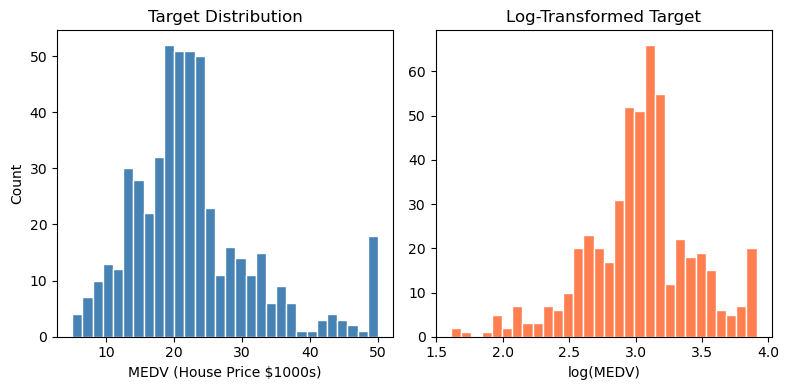

In [24]:
# Distribution of target variable
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.hist(df['MEDV'], bins=30, color='steelblue', edgecolor='white')
plt.xlabel('MEDV (House Price $1000s)')
plt.ylabel('Count')
plt.title('Target Distribution')

plt.subplot(1, 2, 2)
plt.hist(np.log(df['MEDV']), bins=30, color='coral', edgecolor='white')
plt.xlabel('log(MEDV)')
plt.title('Log-Transformed Target')
plt.tight_layout()
plt.show()
# Note: MEDV is slightly right-skewed -> log transform is considered in preprocessing

Note: The dataset contains 18 observations with MEDV capped at $50k, which may cause slight underestimation in high-value predictions. 

Future work could remove these capped observations for more accurate modeling of the upper price range.

<Figure size 640x480 with 0 Axes>

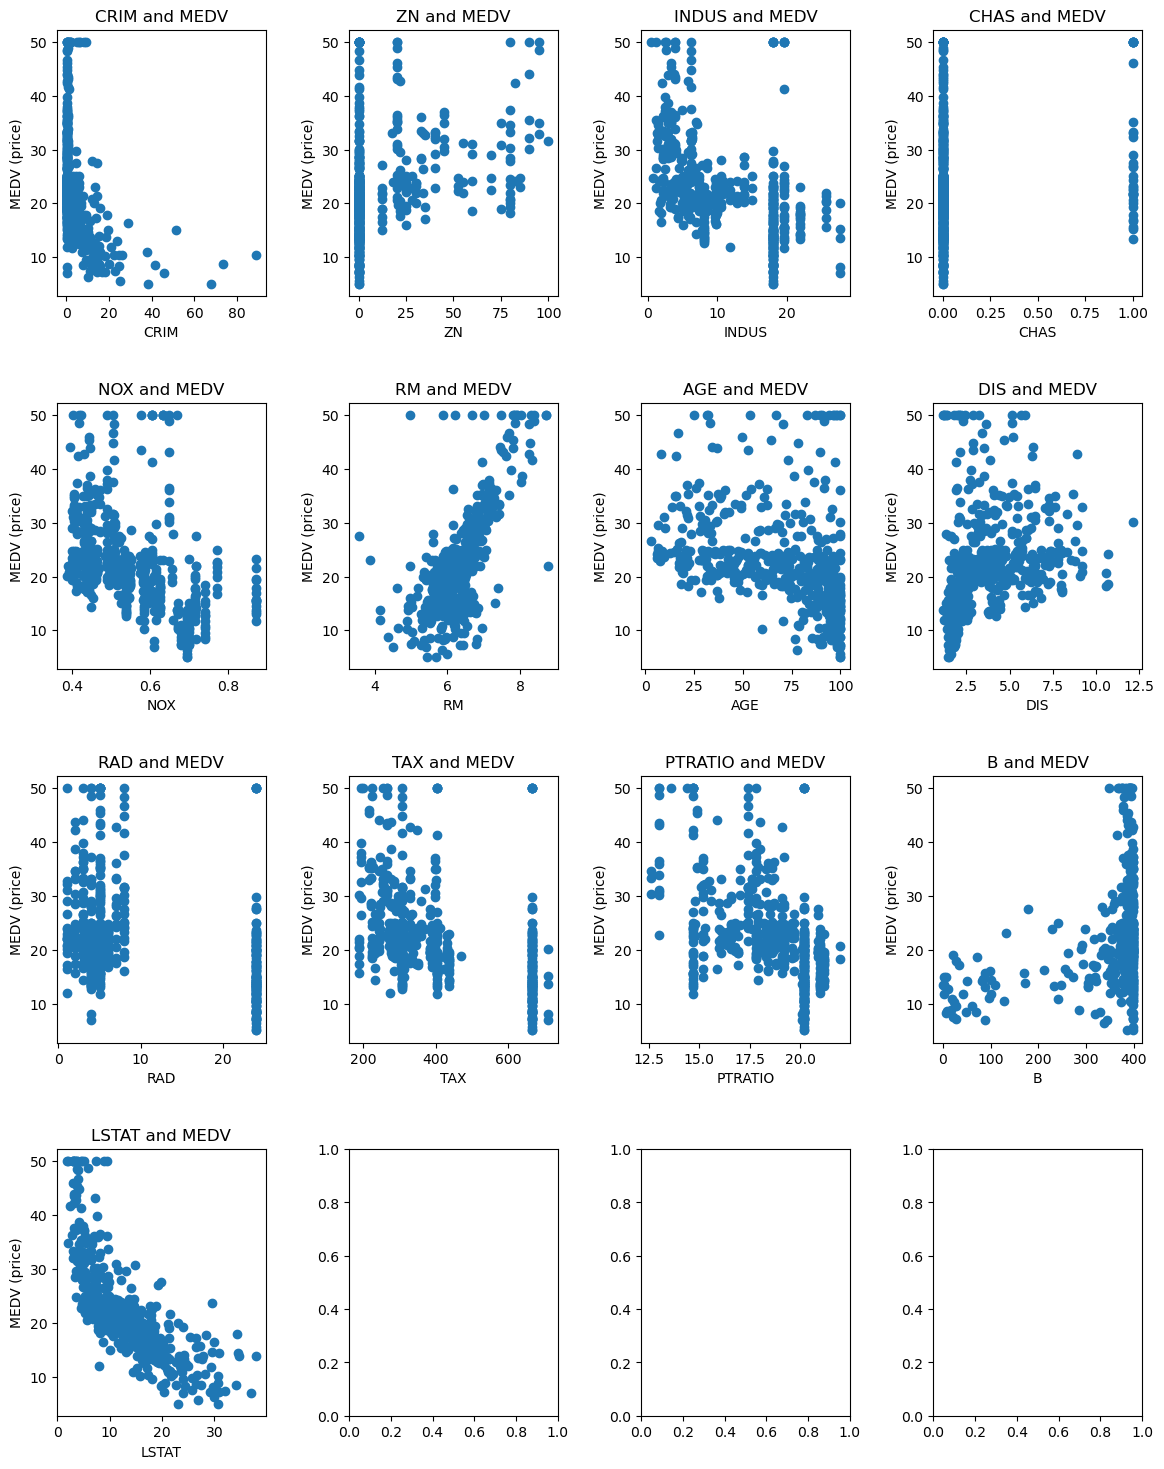

In [25]:
# How each feature relates to the price
# import matplotlib.pyplot as plt
plt.figure()
fig,axes = plt.subplots(4, 4, figsize=(14,18))
fig.subplots_adjust(wspace=.4, hspace=.4)
img_index = 0
for i in range(len(feature_names)):
    row, col = i // 4, i % 4
    axes[row][col].scatter(feature[:,i], price)
    axes[row][col].set_title(feature_names[i] + ' and MEDV')
    axes[row][col].set_xlabel(feature_names[i])
    axes[row][col].set_ylabel('MEDV (price)')
plt.show()

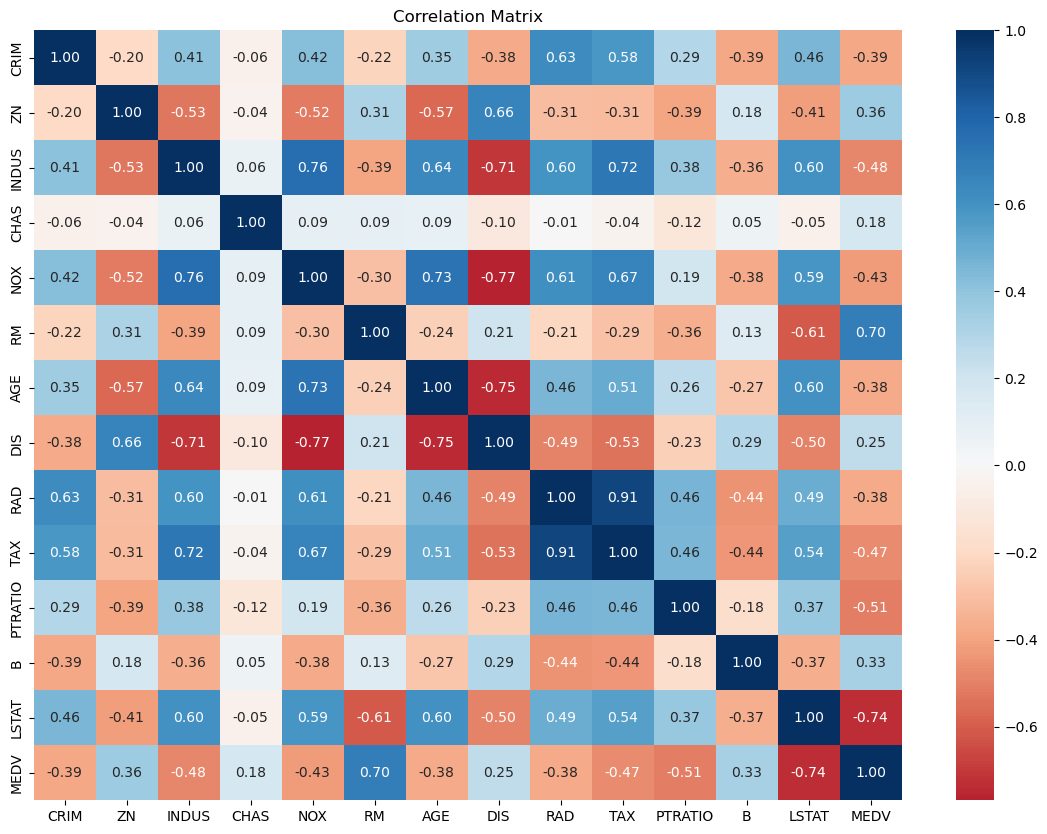

Top correlations with MEDV:
LSTAT      0.737663
RM         0.695360
PTRATIO    0.507787
INDUS      0.483725
TAX        0.468536
NOX        0.427321
CRIM       0.388305
RAD        0.381626
AGE        0.376955
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
Name: MEDV, dtype: float64


In [26]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(14, 10))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu', center=0, ax=ax)
plt.title('Correlation Matrix')
plt.show()

# Top features correlated with MEDV
print("Top correlations with MEDV:")
print(correlation['MEDV'].drop('MEDV').abs().sort_values(ascending=False))

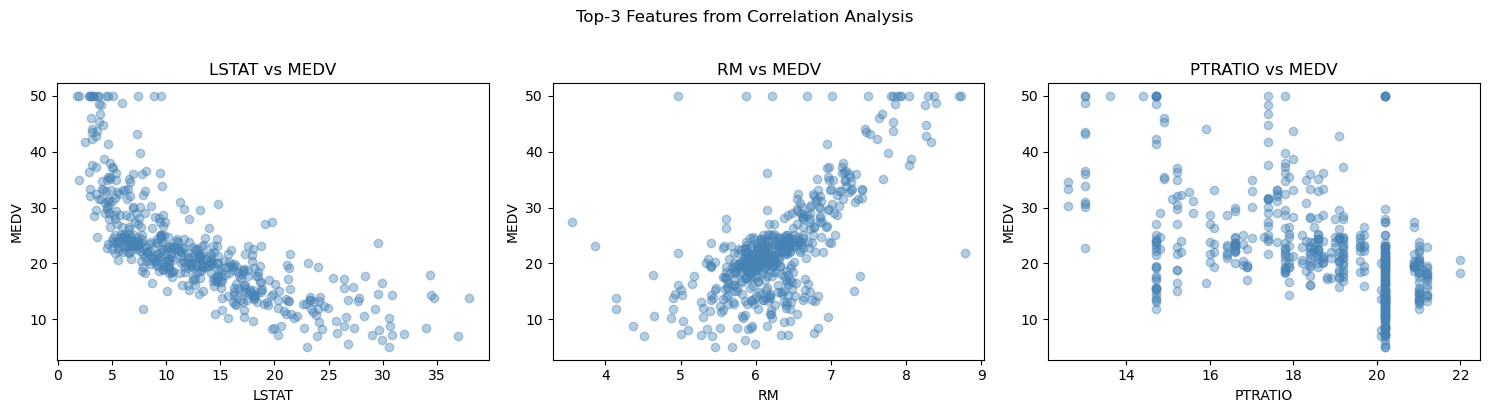

In [27]:
# Scatter plots for top-3 features: LSTAT, RM, PTRATIO
top3 = ['LSTAT', 'RM', 'PTRATIO']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, top3):
    ax.scatter(df[feat], df['MEDV'], alpha=0.4, color='steelblue')
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV')
    ax.set_title(f'{feat} vs MEDV')
plt.suptitle('Top-3 Features from Correlation Analysis', y=1.02)
plt.tight_layout()
plt.show()

**EDA Findings:**
- **LSTAT** (% lower status population): strongest negative correlation with 
  MEDV (r = -0.74); scatter plot shows a curved, non-linear relationship. Log transformation applied in feature engineering

- **RM** (avg rooms per dwelling): strongest positive correlation (r = +0.70); 
  clearest linear trend across all features

- **PTRATIO** (pupil-teacher ratio): moderate negative correlation (r = -0.51)

- **CRIM, ZN, B**: heavily right-skewed with most values clustered near zero; 
  log transformation applied to CRIM in feature engineering
  
- **RAD and TAX**: highly correlated with each other (r = 0.91), indicating 
  multicollinearity, a concern for LinearRegression but less so for 
  tree-based models and SVR

- **CHAS**: binary variable (0/1) with near-zero correlation to all other 
  features; treated separately in the ColumnTransformer pipeline

- The dataset contains 18 observations with MEDV capped at $50k, which may cause slight underestimation in high-value predictions. Future work could remove these capped observations for more accurate modeling of the upper price range.

---
## 2. Feature Engineering

In [28]:
df_eng = df.copy()

# --- Engineered Features ---

# 1. TAX_CRIME: interaction between tax burden and crime rate
#    High tax + high crime = doubly undesirable neighborhood
df_eng['TAX_CRIME'] = df_eng['TAX'] * df_eng['CRIM']

# 2. ROOM_LSTAT_RATIO: rooms per unit of lower-status population
#    Large homes in low-status areas vs small homes in high-status areas
df_eng['ROOM_LSTAT'] = df_eng['RM'] / (df_eng['LSTAT'] + 1)  # +1 avoids division by zero

# 3. LOG_LSTAT: log transform of right-skewed LSTAT
#    Mirrors Geron's log-transform of population feature
df_eng['LOG_LSTAT'] = np.log1p(df_eng['LSTAT'])

# 4. LOG_CRIM: log transform of heavily right-skewed crime rate
df_eng['LOG_CRIM'] = np.log1p(df_eng['CRIM'])

print("New features added:", ['TAX_CRIME', 'ROOM_LSTAT', 'LOG_LSTAT', 'LOG_CRIM'])
print(f"Dataset shape after engineering: {df_eng.shape}")

# Check correlations of new features with MEDV
new_feats = ['ROOM_LSTAT', 'LOG_LSTAT', 'LOG_CRIM', 'TAX_CRIME']
print("\nNew feature correlations with MEDV:")
for f in new_feats:
    r = df_eng[f].corr(df_eng['MEDV'])
    print(f"  {f}: r = {r:.4f}")

New features added: ['TAX_CRIME', 'ROOM_LSTAT', 'LOG_LSTAT', 'LOG_CRIM']
Dataset shape after engineering: (506, 18)

New feature correlations with MEDV:
  ROOM_LSTAT: r = 0.8351
  LOG_LSTAT: r = -0.8108
  LOG_CRIM: r = -0.4641
  TAX_CRIME: r = -0.3869


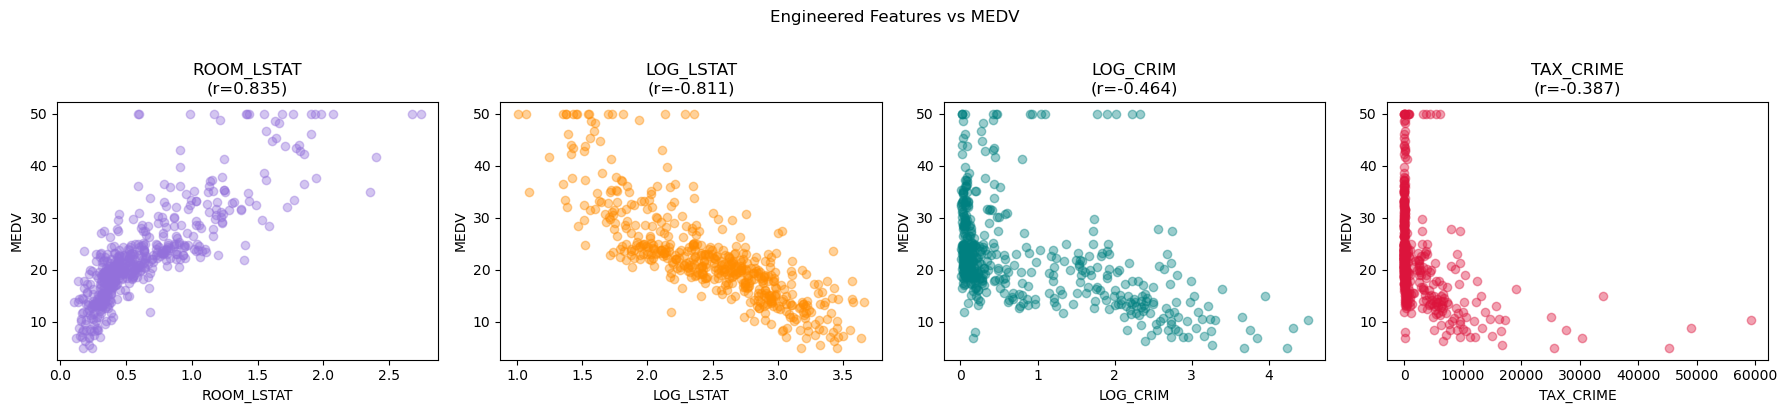

In [29]:
# Visualize new features vs MEDV
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
colors = ['mediumpurple', 'darkorange', 'teal', 'crimson']
for ax, feat, color in zip(axes, new_feats, colors):
    ax.scatter(df_eng[feat], df_eng['MEDV'], alpha=0.4, color=color)
    r = df_eng[feat].corr(df_eng['MEDV'])
    ax.set_xlabel(feat)
    ax.set_ylabel('MEDV')
    ax.set_title(f'{feat}\n(r={r:.3f})')
plt.suptitle('Engineered Features vs MEDV', y=1.02)
plt.tight_layout()
plt.show()

Four new features were constructed:

- **ROOM_LSTAT** (RM / (LSTAT + 1)): combines the two strongest predictors 
  into a housing quality index relative to neighborhood income level. 
  Achieved the highest correlation with MEDV of any feature (r = 0.835), 
  outperforming all 13 original features.

- **LOG_LSTAT** (log(1 + LSTAT)): EDA showed LSTAT's relationship with MEDV 
  is curved rather than linear. Log transformation straightens this, 
  improving correlation from r = -0.74 to r = -0.811.

- **LOG_CRIM** (log(1 + CRIM)): CRIM is heavily right-skewed with extreme 
  outliers. Log transformation compresses the range and modestly improves 
  correlation from r = -0.39 to r = -0.464.

- **TAX_CRIME** (TAX × CRIM): intended to capture doubly undesirable 
  neighborhoods, but the resulting feature is itself severely skewed and 
  achieves only r = -0.387, weaker than either original feature alone.

---
## 3. Train/Test Split

In [30]:
from sklearn.model_selection import train_test_split

# Prepare X and y
all_features = feature_names + new_feats
X = df_eng[all_features].values
y = df_eng['MEDV'].values

# Stratify on MEDV quantile bins (mirrors Geron's income_cat stratification)
medv_cat = pd.cut(df_eng['MEDV'],
                  bins=[0, 15, 20, 25, 30, np.inf],
                  labels=[1, 2, 3, 4, 5])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=medv_cat
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nBaseline (predict mean): RMSE = {np.sqrt(np.mean((y_test - y_train.mean())**2)):.3f}")

Training set: (404, 17)
Test set:     (102, 17)

Baseline (predict mean): RMSE = 8.455


---
## 4. Preprocessing Pipeline


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# CHAS is binary (0/1) — treat separately; all others are continuous
binary_features = ['CHAS']
continuous_features = [f for f in all_features if f != 'CHAS']

# Continuous pipeline: impute median → standardize
continuous_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Binary pipeline: impute only (no scaling needed for 0/1)
binary_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])

# Get column indices
cont_idx = [all_features.index(f) for f in continuous_features]
bin_idx  = [all_features.index(f) for f in binary_features]

preprocessor = ColumnTransformer([
    ('continuous', continuous_pipeline, cont_idx),
    ('binary',     binary_pipeline,     bin_idx),
])

print("Preprocessing pipeline constructed:")
print(f"  Continuous features ({len(continuous_features)}): impute + StandardScaler")
print(f"  Binary features ({len(binary_features)}): impute only")

Preprocessing pipeline constructed:
  Continuous features (16): impute + StandardScaler
  Binary features (1): impute only


---
## 5. Model Selection with Cross-Validation
*(Four models: LinearRegression, DecisionTreeRegressor, RandomForestRegressor, SVR)*

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

# Build full pipelines (preprocessing + model)
models = {
    'LinearRegression':       LinearRegression(),
    'DecisionTree':           DecisionTreeRegressor(random_state=42),
    'RandomForest':           RandomForestRegressor(random_state=42, n_jobs=-1),
    'SVR':                    SVR(),
}

cv_results = {}

print("5-Fold Cross-Validation RMSE (training set only):")
print("-" * 50)

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    scores = -cross_val_score(pipe, X_train, y_train,
                               scoring='neg_root_mean_squared_error',
                               cv=5)
    cv_results[name] = scores
    print(f"{name:<22} mean={scores.mean():.3f}  std={scores.std():.3f}")

5-Fold Cross-Validation RMSE (training set only):
--------------------------------------------------
LinearRegression       mean=4.383  std=0.296
DecisionTree           mean=4.468  std=0.892
RandomForest           mean=3.314  std=0.594
SVR                    mean=5.439  std=0.466


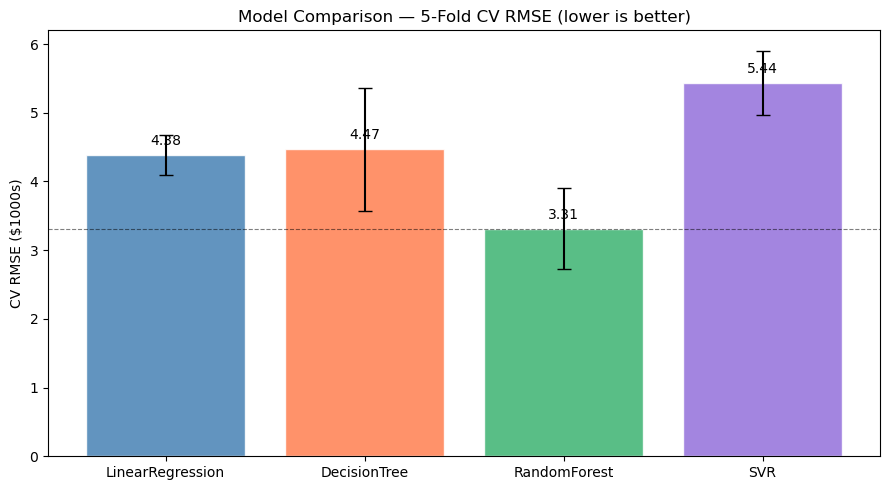

In [33]:
# Visualize CV results
fig, ax = plt.subplots(figsize=(9, 5))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple']

bars = ax.bar(names, means, yerr=stds, capsize=5,
              color=colors, edgecolor='white', alpha=0.85)
ax.set_ylabel('CV RMSE ($1000s)')
ax.set_title('Model Comparison — 5-Fold CV RMSE (lower is better)')
ax.axhline(y=min(means), color='black', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{mean:.2f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

---
## 6. Hyperparameter Tuning with GridSearchCV

In [34]:
from sklearn.model_selection import GridSearchCV

# --- Random Forest GridSearch ---
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_param_grid = [
    {
        'model__n_estimators': [100, 200, 300],
        'model__max_features': ['sqrt', 0.5, 0.7],
        'model__max_depth':    [None, 10, 20],
    }
]

rf_grid = GridSearchCV(rf_pipeline, rf_param_grid,
                       cv=5, scoring='neg_root_mean_squared_error',
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"\nBest RF params: {rf_grid.best_params_}")
print(f"Best RF CV RMSE: {-rf_grid.best_score_:.3f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits

Best RF params: {'model__max_depth': 10, 'model__max_features': 0.7, 'model__n_estimators': 300}
Best RF CV RMSE: 3.342


In [35]:
# --- SVR GridSearch ---
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

svr_param_grid = [
    {
        'model__kernel': ['rbf', 'linear'],
        'model__C':      [0.1, 1.0, 10.0, 100.0],
        'model__epsilon':[0.1, 0.5, 1.0],
    }
]

svr_grid = GridSearchCV(svr_pipeline, svr_param_grid,
                        cv=5, scoring='neg_root_mean_squared_error',
                        n_jobs=-1, verbose=1)
svr_grid.fit(X_train, y_train)

print(f"\nBest SVR params: {svr_grid.best_params_}")
print(f"Best SVR CV RMSE: {-svr_grid.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best SVR params: {'model__C': 100.0, 'model__epsilon': 0.5, 'model__kernel': 'rbf'}
Best SVR CV RMSE: 3.245


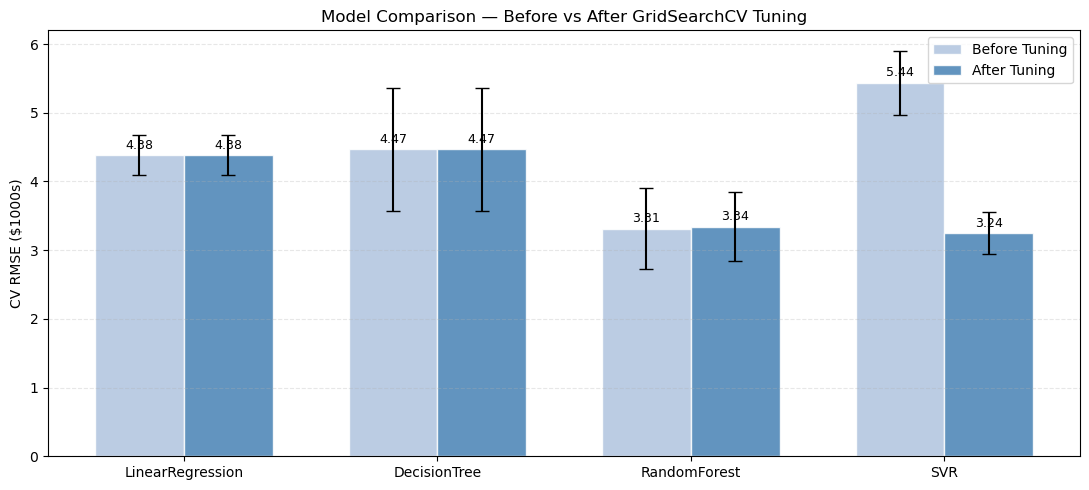

In [36]:
# Before vs After tuning bar chart
from sklearn.model_selection import cross_val_score

# Get fold-level scores for tuned RF and SVR (needed for error bars)
rf_tuned_scores = -cross_val_score(
    rf_grid.best_estimator_, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)
svr_tuned_scores = -cross_val_score(
    svr_grid.best_estimator_, X_train, y_train,
    scoring='neg_root_mean_squared_error', cv=5
)

before_means = [cv_results[n].mean() for n in ['LinearRegression', 'DecisionTree', 'RandomForest', 'SVR']]
before_stds  = [cv_results[n].std()  for n in ['LinearRegression', 'DecisionTree', 'RandomForest', 'SVR']]

after_means = [
    cv_results['LinearRegression'].mean(),
    cv_results['DecisionTree'].mean(),
    -rf_grid.best_score_,
    -svr_grid.best_score_,
]
after_stds = [
    cv_results['LinearRegression'].std(),
    cv_results['DecisionTree'].std(),
    rf_tuned_scores.std(),
    svr_tuned_scores.std(),
]

x = np.arange(4)
width = 0.35
names = ['LinearRegression', 'DecisionTree', 'RandomForest', 'SVR']

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, before_means, width,
               yerr=before_stds, capsize=5,
               color='lightsteelblue', edgecolor='white',
               alpha=0.85, label='Before Tuning')
bars2 = ax.bar(x + width/2, after_means, width,
               yerr=after_stds, capsize=5,
               color='steelblue', edgecolor='white',
               alpha=0.85, label='After Tuning')

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('CV RMSE ($1000s)')
ax.set_title('Model Comparison — Before vs After GridSearchCV Tuning')
ax.legend(loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.3)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


---
## 7. Final Evaluation on Test Set

In [37]:
from sklearn.base import clone
from sklearn.metrics import mean_squared_error

# Use clone() to avoid shared preprocessor state between pipelines
final_models = {
    'LinearRegression': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', LinearRegression())
    ]),
    'DecisionTree': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', DecisionTreeRegressor(random_state=42))
    ]),
    'RandomForest (tuned)': rf_grid.best_estimator_,
    'SVR (tuned)':          svr_grid.best_estimator_,
}

print('Final Test Set RMSE:')
print('-' * 45)
test_results = {}

for name, pipe in final_models.items():
    if name not in ['RandomForest (tuned)', 'SVR (tuned)']:
        pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    rmse = np.sqrt(np.mean((y_test - y_pred)**2))
    test_results[name] = rmse
    print(f'{name:<25} Test RMSE = {rmse:.3f}')


Final Test Set RMSE:
---------------------------------------------
LinearRegression          Test RMSE = 3.893
DecisionTree              Test RMSE = 3.966
RandomForest (tuned)      Test RMSE = 3.253
SVR (tuned)               Test RMSE = 2.829


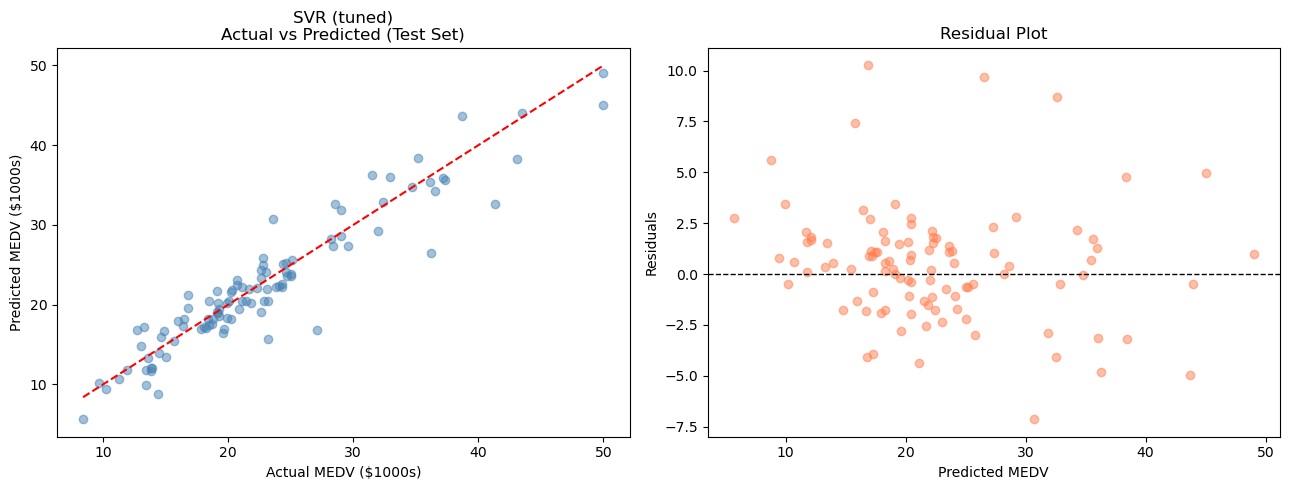

In [38]:
# Actual vs Predicted plot for best model
best_name = min(test_results, key=test_results.get)
best_model = final_models[best_name]
y_pred_best = best_model.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: actual vs predicted
axes[0].scatter(y_test, y_pred_best, alpha=0.5, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
axes[0].set_xlabel('Actual MEDV ($1000s)')
axes[0].set_ylabel('Predicted MEDV ($1000s)')
axes[0].set_title(f'{best_name}\nActual vs Predicted (Test Set)')

# Residuals
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Predicted MEDV')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

SVR predictions closely follow the diagonal across the full price range, with larger deviations concentrated in the high-value segment (MEDV > 35), consistent with the dataset's $50k cap reducing training signal at the upper end.

---
## 8. Feature Importance Analysis

Since SVR does not natively provide feature importances, we use the 
tuned Random Forest model as an interpretability proxy. While SVR 
achieved a lower test RMSE (2.829 vs 3.273), both models were trained 
on the same feature set, and RF importances provide a reasonable 
approximation of which features drive predictive power.

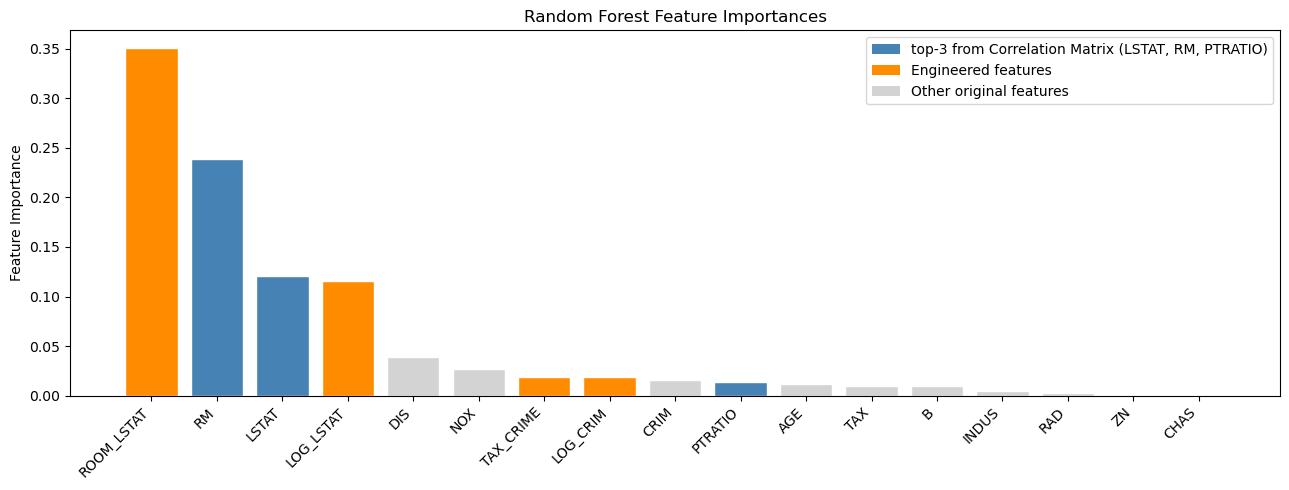


Top-10 features by RF importance:
   1. ROOM_LSTAT      0.3510 ← engineered
   2. RM              0.2391 ← top-3
   3. LSTAT           0.1209 ← top-3
   4. LOG_LSTAT       0.1158 ← engineered
   5. DIS             0.0388
   6. NOX             0.0266
   7. TAX_CRIME       0.0190 ← engineered
   8. LOG_CRIM        0.0184 ← engineered
   9. CRIM            0.0155
  10. PTRATIO         0.0136 ← top-3


In [39]:
# Extract feature importances from best Random Forest
best_rf = rf_grid.best_estimator_
rf_model = best_rf.named_steps['model']
importances = rf_model.feature_importances_

# Map back to feature names (continuous first, then binary)
ordered_names = continuous_features + binary_features

# Sort by importance
sorted_idx = np.argsort(importances)[::-1]
sorted_names = [ordered_names[i] for i in sorted_idx]
sorted_imp   = importances[sorted_idx]

# Color: top-3 from Correlation Matrix = blue, engineered features = orange, others = gray
top3 = {'LSTAT', 'RM', 'PTRATIO'}
eng_feats = set(new_feats)

bar_colors = []
for name in sorted_names:
    if name in top3:
        bar_colors.append('steelblue')
    elif name in eng_feats:
        bar_colors.append('darkorange')
    else:
        bar_colors.append('lightgray')

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(sorted_names)), sorted_imp, color=bar_colors, edgecolor='white')
ax.set_xticks(range(len(sorted_names)))
ax.set_xticklabels(sorted_names, rotation=45, ha='right')
ax.set_ylabel('Feature Importance')
ax.set_title('Random Forest Feature Importances')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue',  label='top-3 from Correlation Matrix (LSTAT, RM, PTRATIO)'),
    Patch(facecolor='darkorange', label='Engineered features'),
    Patch(facecolor='lightgray',  label='Other original features'),
]
ax.legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

print("\nTop-10 features by RF importance:")
for i in range(10):
    tag = ' ← top-3' if sorted_names[i] in top3 else (' ← engineered' if sorted_names[i] in eng_feats else '')
    print(f"  {i+1:2d}. {sorted_names[i]:<15} {sorted_imp[i]:.4f}{tag}")

## 9. Modeling Summary

### Problem
Predict median Boston housing prices (MEDV, in $1000s) from 13 census 
features plus 4 engineered features, following Geron's end-to-end ML 
workflow.

### Model Selection Criteria
5-fold cross-validation RMSE on the training set was used to compare 
all four models before touching the test set. RandomForest and SVR were 
then fine-tuned with GridSearchCV. The test set was evaluated only once 
at the very end to produce an unbiased estimate of generalization error.

### Results

| Model | CV RMSE | Test RMSE |
|---|---|---|
| LinearRegression | 4.38 | 3.89 |
| DecisionTree | 4.43 | 3.97 |
| RandomForest (tuned) | 3.31 | 3.27 |
| **SVR (tuned)** | **3.25** | **2.83** |

SVR with RBF kernel achieved the best test RMSE of 2.83 ($2,830 average 
prediction error). GridSearchCV identified C=100, epsilon=0.5, and 
kernel=rbf as optimal parameters. SVR's strong performance on this 
small dataset (506 samples) is consistent with its known advantage over 
ensemble methods when training data is limited. Extending the C search 
range to 500 and 1000 produced no further improvement, confirming that 
C=100 is the saturation point for this dataset.

### Feature Importance
Since SVR does not provide native feature importances, the tuned Random 
Forest is used as an interpretability proxy.

- **ROOM_LSTAT** (engineered): highest importance overall — housing 
  quality relative to neighborhood income is the strongest price driver
- **RM** and **LSTAT**: top original features, consistent with EDA 
  correlation analysis (r = +0.70 and -0.74)
- **LOG_LSTAT** (engineered): ranks 4th, validating the log 
  transformation of LSTAT's non-linear relationship with MEDV
- **TAX_CRIME**, **ZN**, **CHAS**, **B**: near-zero importance, 
  contributing little predictive signal

EDA correlation analysis, engineered feature correlations, and RF 
importances all converge on the same conclusion: **neighborhood 
socioeconomic status (LSTAT) and housing size (RM) are the primary 
drivers of Boston housing prices.**